# Final Project: Kalshi Market Making in short-dated SPX Events

Chris Mulligan (12502987), George Lord (12243747), Max Zhalilo (12341701)

# Content

0. Abstract
1. Introduction
2. Data
3. Techniques and Theory Details in the Strategy
4. Implementation of our Strategy
5. Result/Analysis

# 0. Abstract

We use statistical modeling & black-scholes to price Kalshi short-dates SPX events. We simulate an automated market making strategy in these events using a simulator that directly interfaces with our trading modules. We delta hedge SPX exposure by trading the SPY ETF. We test the performance of our strategy over 2 months.

# 1. Introduction

In modern financial markets, algorithmic trading and automated market making have become central components of liquidity provision and price discovery. Electronic Market Makers such as Jump & Virtu have begun to expand into prediction markets such as Kalshi & Polymarket to profit from their increasing trading volumes. In this project, we develop and test a fully systematic market-making strategy for short-dated S&P 500 (SPX) event contracts listed on Kalshi. These contracts pay a fixed $1 if a specified event occurs—such as the SPX closing above a certain level-and $0 otherwise. As a result, they can be interpreted as binary options on the terminal value of the SPX index.

The core idea of our strategy is grounded in Black-Scholes derivative pricing theory. A binary call option has a value equal to the discounted risk-neutral probability that the underlying asset finishes above a given strike at expiration. For contracts with 0–1 days to expiration, discounting effects are negligible (??? LETS THINK ABOUT THIS ???), so the contract price closely approximates the market-implied probability of the event occurring. By modeling the terminal distribution of SPX under a log-normal assumption consistent with the Black–Scholes framework, we can estimate these probabilities analytically using closed-form expressions. Specifically, we compute the cumulative distribution function (CDF) implied by current SPX levels, time to expiration, and volatility, with volatility proxied by the VIX index.

Once fair values for binary calls and puts are obtained, we replicate the payoff structures of Kalshi’s SPX “above” and “range” contracts using combinations of these binaries. This replication framework provides a theoretical benchmark price for each listed contract. The strategy then centers its market-making quotes around these fair values and dynamically adjusts bid–ask spreads as a function of market volatility, time to expiration, tick size constraints, exchange fees, and current inventory. In higher-volatility or low-liquidity environments, spreads are widened to compensate for increased uncertainty and adverse selection risk.

Because the fair value of each contract is sensitive to movements in the underlying SPX index, holding inventory in Kalshi contracts introduces directional exposure. To manage this risk, we compute the delta of each replicated binary position with respect to SPX and aggregate the book’s total delta exposure. We then hedge this exposure using the SPY ETF, which closely tracks SPX movements. This delta-hedging process isolates the strategy’s profit and loss primarily to bid–ask spread capture and pricing inefficiencies rather than outright market direction.

We test our strategy in a simulator that mimics Kalshi exchange capability. We've built out our strategy using pricing, market making, hedging, & position management modules, all of which interact with the simulator using our execution engine module. Our objective is to assess whether theoretically grounded probability estimates, combined with disciplined spread management and delta hedging, can generate consistent risk-adjusted returns in short-dated event markets.

# 2. Data

This section describes the five datasets used in our simulation, the structure of Kalshi SPX contracts, our data preprocessing pipeline, and the market environment during our test period (January 2 – February 26, 2026).

## 2.1 Data Sources

Our strategy relies on five datasets: two macro series (SPX and VIX) sourced from Bloomberg at 1-second resolution, one equity ETF series (SPY) from Databento at 1-second OHLCV resolution, and two Kalshi contract trade-event feeds pulled via the Kalshi API. All macro data covers the full extended-hours session; SPY is limited to regular trading hours. Kalshi data is at the trade-event level and bucketed to 1-second bars during preprocessing (described in Section 2.3).

In [ ]:
import polars as pl
import pandas as pd
from IPython.display import display
from datetime import datetime

spx    = pl.read_parquet("Data/Cleaned Input Parquets/spx_clean.parquet")
vix    = pl.read_parquet("Data/Cleaned Input Parquets/vix_clean.parquet")
spy    = pl.read_parquet("Data/Cleaned Input Parquets/spy_clean.parquet")
kxinx  = pl.read_parquet("Data/Cleaned Input Parquets/kalshi_kxinx_clean.parquet")
kxinxu = pl.read_parquet("Data/Cleaned Input Parquets/kalshi_kxinxu_clean.parquet")

def fmt_ts(ts):
    return ts.strftime("%b %d, %Y")

def fmt_date(d):
    return datetime.strptime(d, "%Y-%m-%d").strftime("%b %d, %Y")

rows = [
    ("SPX",
     "Bloomberg", "1-second",
     f"{fmt_ts(spx['ts'].min())} – {fmt_ts(spx['ts'].max())}",
     f"{spx.height:,}", "Extended hours"),
    ("VIX",
     "Bloomberg", "1-second",
     f"{fmt_ts(vix['ts'].min())} – {fmt_ts(vix['ts'].max())}",
     f"{vix.height:,}", "Extended hours"),
    ("SPY",
     "Databento", "1-second OHLCV",
     f"{fmt_ts(spy['ts'].min())} – {fmt_ts(spy['ts'].max())}",
     f"{spy.height:,}", "RTH only (9:30–16:00 ET)"),
    ("KXINX (range)",
     "Kalshi API", "Trade-event",
     f"{fmt_date(kxinx['date'].min())} – {fmt_date(kxinx['date'].max())}",
     f"{kxinx.height:,}", f"{kxinx['ticker'].n_unique()} contracts, {kxinx['date'].n_unique()} trading days"),
    ("KXINXU (threshold)",
     "Kalshi API", "Trade-event",
     f"{fmt_date(kxinxu['date'].min())} – {fmt_date(kxinxu['date'].max())}",
     f"{kxinxu.height:,}", f"{kxinxu['ticker'].n_unique()} contracts, {kxinxu['date'].n_unique()} trading days"),
]

summary = pd.DataFrame(rows, columns=["Dataset", "Source", "Frequency", "Period", "Records", "Coverage"])
display(summary.set_index("Dataset"))

## 2.2 Kalshi Contract Structure

Kalshi lists two families of short-dated SPX event contracts, both settling at 4:00 PM ET on the expiration date. Each contract pays $1 if the event occurs and $0 otherwise, so prices trade in $[0.01, 0.99]$ and represent market-implied probabilities.

**KXINXU — Threshold contracts.**  
A YES contract pays $1 if SPX closes *strictly above* a stated threshold $K$ at expiry. A NO contract pays $1 if SPX closes *at or below* $K$. YES contracts are therefore binary calls on SPX; NO contracts are binary puts.  
Example: `KXINXU-26JAN02H1600-T6799.9999` — YES pays if SPX > 6799.9999 at 4 PM ET on Jan 2, 2026.

**KXINX — Range contracts.**  
A YES contract pays $1 if SPX closes inside a 25-point range $(\text{lower}, \text{upper}]$ at expiry, equivalent to a binary call spread (long binary call at the lower strike, short at the upper). A NO contract is the complementary strangle.  
Example: `KXINX-26JAN02H1600-B6787` — the bucket token `B6787` encodes a midpoint of 6787.5, giving the range $(6775, 6800]$. YES pays if $6775 < \text{SPX} \leq 6800$ at expiry.

**Contract ID encoding.**  
Both formats embed the expiry date/time and strike information directly in the ticker:
```
KXINXU - 26JAN02 H1600 - T6799.9999
KXINX  - 26JAN02 H1600 - B6787
          ↑              ↑
    YY MON DD H HHMM   T=threshold, B=bucket midpoint
```

**Kalshi trade-event data.**  
Rather than a live order book, we observe individual trade events with a `liquidity_event` field: `hit_bid` (a taker sold, hitting the resting bid) or `lift_offer` (a taker bought, lifting the resting offer). These events are bucketed to 1-second bars to produce the `take_bid` and `take_ask` prices used by our fill detection logic.

In [ ]:
# Show one representative row from each contract type
print("=== KXINXU (threshold) sample ===")
display(kxinxu.select(["ticker", "contract_desc", "threshold", "ts", "price", "quantity", "liquidity_event"]).head(3).to_pandas())

print("\n=== KXINX (range) sample ===")
display(kxinx.select(["ticker", "contract_desc", "bracket_floor", "bracket_cap", "ts", "price", "quantity", "liquidity_event"]).head(3).to_pandas())

## 2.3 Data Preprocessing

Raw data from each source requires several cleaning steps before it can be used by the simulation. The pipeline is implemented in `DataIngestor.py` and proceeds as follows.

**Macro data (SPX, VIX, SPY).** Bloomberg and Databento exports are already at 1-second resolution. Each file is read, the timestamp column is standardized to a timezone-aware datetime, and the relevant value column is selected (e.g. `close` for SPY). SPX, VIX, and SPY are then joined on `ts` to form a single macro DataFrame.

**Kalshi trade-event data.** Each raw row is one trade event. To align with the 1-second macro data, events are bucketed: timestamps are truncated to the second, then grouped by `(ts, contract_id)`. Within each bucket, `take_bid` is set to the minimum price of all `hit_bid` events (the lowest level at which our resting bid would have been hit), and `take_ask` to the maximum price of all `lift_offer` events (the highest level at which our resting offer would have been lifted). Buckets with no events on either side are dropped.

**Join and gap-filling.** The 1-second Kalshi data is left-joined to the macro DataFrame on `ts`. Because Kalshi trades are sparse and occur at irregular sub-second timestamps, many Kalshi rows have no exact macro match after bucketing. Missing macro values (SPX, VIX, SPY) are forward-filled then backward-filled within the sorted DataFrame; any rows that remain null after filling are dropped. The output `all_df` is a long-form DataFrame with one row per `(ts, contract_id)`.

In [ ]:
import sys
sys.path.insert(0, "src")

from DataIngestor import DataIngestor, KalshiCleanSpec, MacroSpec

ingestor = DataIngestor()
all_df, macro_df = ingestor.load(
    kalshi_clean_files=[
        KalshiCleanSpec(path="Data/Cleaned Input Parquets/kalshi_kxinx_clean.parquet"),
        KalshiCleanSpec(path="Data/Cleaned Input Parquets/kalshi_kxinxu_clean.parquet"),
    ],
    spx=MacroSpec(path="Data/Cleaned Input Parquets/spx_clean.parquet", value_col="spx"),
    vix=MacroSpec(path="Data/Cleaned Input Parquets/vix_clean.parquet", value_col="vix"),
    spy=MacroSpec(path="Data/Cleaned Input Parquets/spy_clean.parquet", value_col="close"),
)

# Gap-fill macro values for Kalshi rows without an exact 1s macro match
pre_rows = all_df.height
all_df = (
    all_df.sort(["ts", "contract_id"])
    .with_columns([
        pl.col("spx").forward_fill().backward_fill(),
        pl.col("vix").forward_fill().backward_fill(),
        pl.col("spy").forward_fill().backward_fill(),
    ])
    .filter(pl.col("spx").is_not_null() & pl.col("vix").is_not_null() & pl.col("spy").is_not_null())
)

print(f"Kalshi trade buckets (rows in all_df): {all_df.height:,}  ({pre_rows - all_df.height} dropped after gap-fill)")
print(f"Macro rows (1s SPX/VIX/SPY):           {macro_df.height:,}")
print(f"Unique contracts in all_df:             {all_df['contract_id'].n_unique()}")
print()
display(all_df.head(5).to_pandas())

## 2.4 Market Environment During the Test Period

The simulation covers 38 trading days from January 2 to February 26, 2026. Understanding the macro environment matters for interpreting results: VIX enters directly into our spread formula (wider spreads in higher vol), and large SPX moves stress-test the delta hedging component.

The charts below show daily closing SPX and VIX over the period, followed by summary statistics.

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Daily close: last observed value of each trading day
spx_pd = spx.to_pandas()
spx_pd["date"] = pd.to_datetime(spx_pd["date"])
spx_daily = spx_pd.groupby("date")["spx"].last().reset_index().sort_values("date")

vix_pd = vix.to_pandas()
vix_pd["date"] = pd.to_datetime(vix_pd["date"])
vix_daily = vix_pd.groupby("date")["vix"].last().reset_index().sort_values("date")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=False)
fig.suptitle("Market Environment: January 2 – February 26, 2026", fontsize=13, fontweight="bold")

ax1.plot(spx_daily["date"], spx_daily["spx"], color="steelblue", linewidth=1.5)
ax1.set_ylabel("Index Level")
ax1.set_title("S&P 500 (SPX) — Daily Close")
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax1.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=2))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30, ha="right")

ax2.plot(vix_daily["date"], vix_daily["vix"], color="tomato", linewidth=1.5)
ax2.set_ylabel("VIX Level")
ax2.set_title("CBOE VIX — Daily Close")
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax2.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=2))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha="right")

plt.tight_layout()
plt.show()

# Summary stats
spx_start = spx_daily["spx"].iloc[0]
spx_end   = spx_daily["spx"].iloc[-1]
spx_ret   = (spx_end / spx_start - 1) * 100
print(f"SPX:  start={spx_start:.2f}  end={spx_end:.2f}  return={spx_ret:+.2f}%"
      f"  daily range=[{spx_daily['spx'].min():.2f}, {spx_daily['spx'].max():.2f}]")
print(f"VIX:  min={vix_daily['vix'].min():.2f}  mean={vix_daily['vix'].mean():.2f}"
      f"  max={vix_daily['vix'].max():.2f}")

## 2.5 Data Limitations

Three limitations of the data are worth noting because they directly affect how simulation results should be interpreted.

**No live order book.** The Kalshi feed provides trade events rather than full order book snapshots. We observe prices and sizes *where trades actually occurred*, not the standing depth at every moment. This means our fill simulation cannot be validated against a true queue; instead we adopt the conservative last-in-queue assumption (our resting order is filled only when a taker pushes through our price level by one full tick). Actual fill rates on a live system could be higher or lower depending on queue position.

**SPY is RTH-only.** The SPY OHLCV data covers regular trading hours (9:30–16:00 ET) only. Kalshi contracts trade 24/7, so after-hours and pre-market Kalshi rows use a forward-filled SPY price from the prior session close. Delta hedge calculations and SPY-based equity mark-to-market outside RTH are therefore approximate.

**VIX as flat volatility.** VIX is a 30-day implied volatility index. Using it as a flat, term-structure-free volatility (σ = VIX / 100) is a deliberate simplification consistent with the Black–Scholes framework. For 0–1 DTE contracts the term structure and vol smile effects are more pronounced than for longer-dated options, so our fair values carry model risk that grows as a contract approaches expiry. This is partially mitigated by the inventory and VIX-based spread widening, but it remains a source of pricing error.

## 2.6 Intraday Trade Activity

Understanding *when* Kalshi trading happens is essential for evaluating our strategy. Two key questions: (1) How is trading concentrated across the day? (2) Does activity vary across the 2-month period?

The first chart shows trade counts by hour of day (ET) across all contracts and all days. The second shows daily trade volume broken down by contract type.

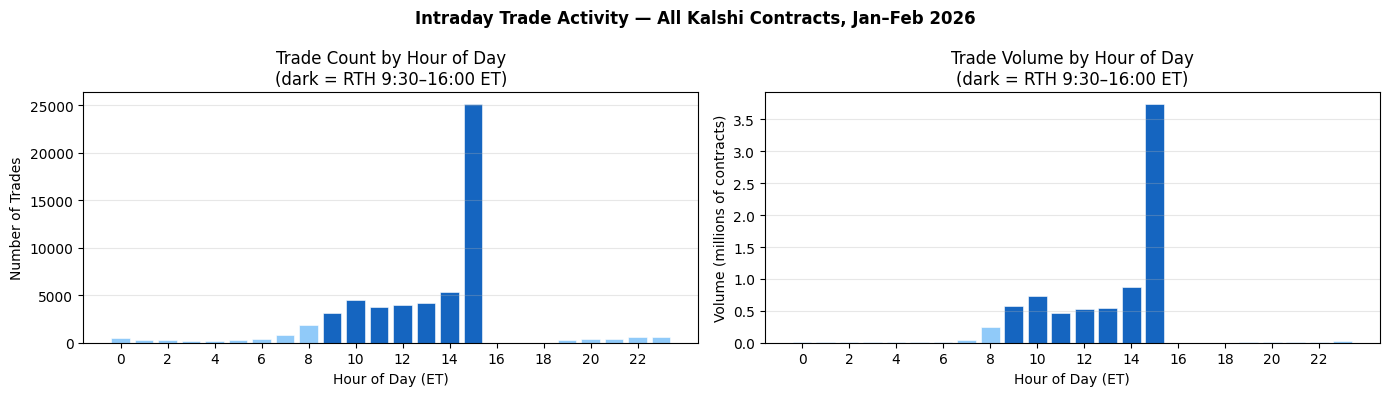

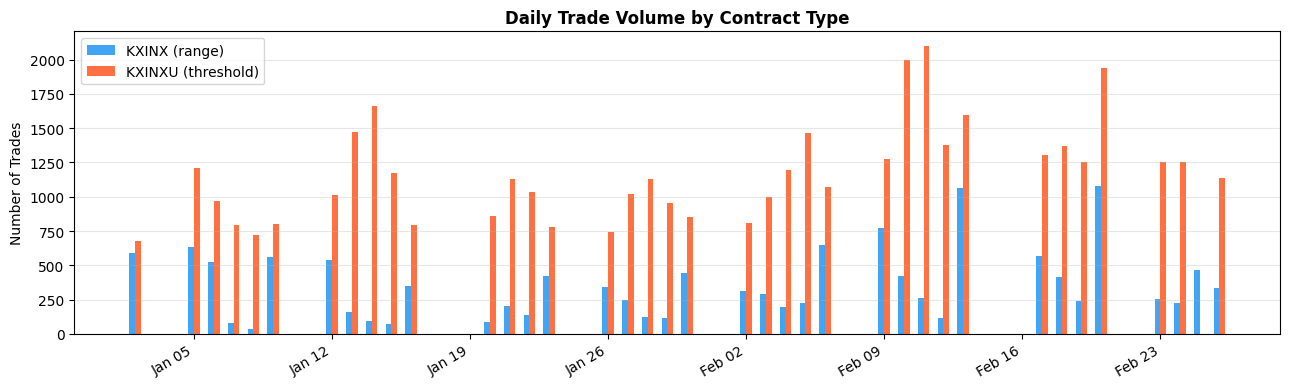

Hour 15 (3–4PM ET): 25,103 trades  (6.1x the avg of other RTH hours)
After-hours (16:00–09:29): 6,862 trades  (12.1% of total)


In [5]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

# ── Shared setup: SPX daily close + per-contract daily VWAPs ─────────────────
spx_close_daily = (
    spx.sort("ts")
    .group_by("date")
    .agg(pl.col("spx").last().alias("spx_close"))
    .sort("date")
)

kxinx_vwap = (
    kxinx
    .group_by(["date", "ticker", "bracket_floor", "bracket_cap", "side_of_close"])
    .agg(
        (pl.col("price") * pl.col("quantity")).sum().alias("pq"),
        pl.col("quantity").sum().alias("total_qty"),
    )
    .with_columns((pl.col("pq") / pl.col("total_qty")).alias("vwap"))
    .join(spx_close_daily, on="date", how="left")
    .with_columns(
        pl.when(pl.col("side_of_close") == "above")
          .then(pl.col("bracket_floor") - pl.col("spx_close"))
          .otherwise(pl.col("spx_close") - pl.col("bracket_cap"))
          .alias("distance_from_close")
    )
)

kxinxu_vwap = (
    kxinxu
    .group_by(["date", "ticker", "threshold", "side_of_close"])
    .agg(
        (pl.col("price") * pl.col("quantity")).sum().alias("pq"),
        pl.col("quantity").sum().alias("total_qty"),
    )
    .with_columns((pl.col("pq") / pl.col("total_qty")).alias("vwap"))
    .join(spx_close_daily, on="date", how="left")
    .with_columns(
        pl.when(pl.col("side_of_close") == "above")
          .then(pl.col("threshold") - pl.col("spx_close"))
          .otherwise(pl.col("spx_close") - pl.col("threshold"))
          .alias("distance_from_close")
    )
)

# ── Chart 1: Trade count by hour of day (ET) ─────────────────────────────────
k_all = pl.concat([
    kxinx.select(["ts", "quantity"]),
    kxinxu.select(["ts", "quantity"]),
])
hour_agg = (
    k_all
    .with_columns(pl.col("ts").dt.hour().alias("hour"))
    .group_by("hour")
    .agg(pl.len().alias("n_trades"), pl.col("quantity").sum().alias("volume"))
    .sort("hour")
    .to_pandas()
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

rth_mask = (hour_agg["hour"] >= 9) & (hour_agg["hour"] < 16)
colors = ["#1565c0" if m else "#90caf9" for m in rth_mask]
ax1.bar(hour_agg["hour"], hour_agg["n_trades"], color=colors, edgecolor="white", linewidth=0.4)
ax1.set_xlabel("Hour of Day (ET)")
ax1.set_ylabel("Number of Trades")
ax1.set_title("Trade Count by Hour of Day\n(dark = RTH 9:30–16:00 ET)")
ax1.set_xticks(range(0, 24, 2))
ax1.grid(axis="y", alpha=0.3)

ax2.bar(hour_agg["hour"], hour_agg["volume"] / 1e6, color=colors, edgecolor="white", linewidth=0.4)
ax2.set_xlabel("Hour of Day (ET)")
ax2.set_ylabel("Volume (millions of contracts)")
ax2.set_title("Trade Volume by Hour of Day\n(dark = RTH 9:30–16:00 ET)")
ax2.set_xticks(range(0, 24, 2))
ax2.grid(axis="y", alpha=0.3)

plt.suptitle("Intraday Trade Activity — All Kalshi Contracts, Jan–Feb 2026", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

# ── Chart 2: Daily trade volume by contract type ──────────────────────────────
kxinx_daily  = kxinx.group_by("date").agg(pl.len().alias("trades")).sort("date").to_pandas()
kxinxu_daily = kxinxu.group_by("date").agg(pl.len().alias("trades")).sort("date").to_pandas()
kxinx_daily["date"]  = pd.to_datetime(kxinx_daily["date"])
kxinxu_daily["date"] = pd.to_datetime(kxinxu_daily["date"])

fig, ax = plt.subplots(figsize=(13, 4))
width = pd.Timedelta(hours=7)
ax.bar(kxinx_daily["date"]  - width / 2, kxinx_daily["trades"],  width=width, color="#2196F3", alpha=0.85, label="KXINX (range)")
ax.bar(kxinxu_daily["date"] + width / 2, kxinxu_daily["trades"], width=width, color="#FF5722", alpha=0.85, label="KXINXU (threshold)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
fig.autofmt_xdate(rotation=30)
ax.set_ylabel("Number of Trades")
ax.set_title("Daily Trade Volume by Contract Type", fontsize=12, fontweight="bold")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Key stats
last_hour = hour_agg[hour_agg["hour"] == 15]["n_trades"].values[0]
other_rth = hour_agg[(hour_agg["hour"] >= 9) & (hour_agg["hour"] < 15)]["n_trades"].mean()
print(f"Hour 15 (3–4PM ET): {last_hour:,} trades  ({last_hour/other_rth:.1f}x the avg of other RTH hours)")
print(f"After-hours (16:00–09:29): {hour_agg[~rth_mask]['n_trades'].sum():,} trades  ({hour_agg[~rth_mask]['n_trades'].sum()/(hour_agg['n_trades'].sum())*100:.1f}% of total)")

## 2.7 Contract Price Convergence

Two charts characterize what Kalshi markets *look like* in practice and validate that they behave as binary options theory predicts.

**Price convergence through the day.** On the busiest trading day in the dataset, we plot the intraday price path of the 5 KXINX brackets nearest to the eventual SPX close. Each contract starts the session at some probability and should converge to either $1.00 (YES settles) or $0.00 (NO settles) by 4PM ET. This is the core dynamic our market maker operates in.

**Implied probability vs distance from close.** Across all contracts and all days, we compute each contract's daily volume-weighted average price (VWAP) and the distance between the SPX daily close and the nearest bracket edge. Under the lognormal model, out-of-the-money contracts should trade at declining implied probabilities as distance from ATM increases, with the relationship following the shape of the normal CDF. The scatter validates this empirically.

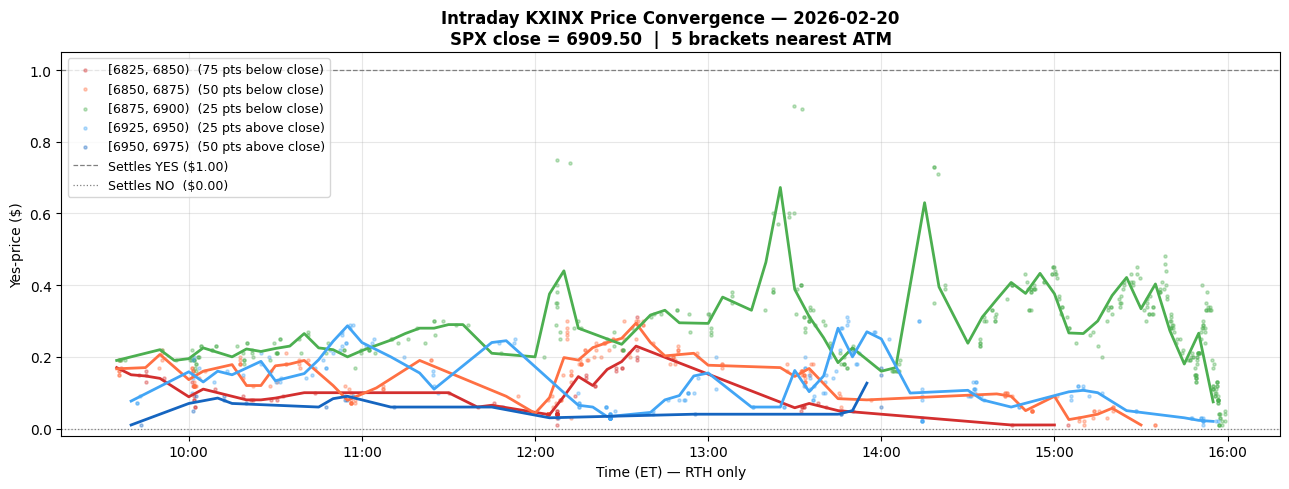

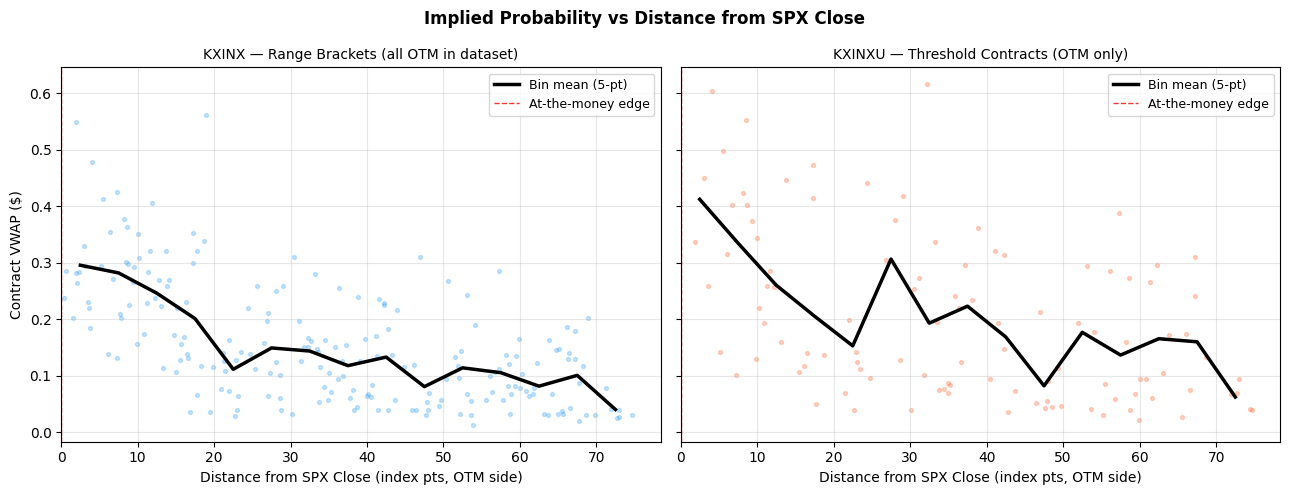

In [6]:
# ── Chart 1: Intraday price convergence on busiest KXINX day ─────────────────
busiest_date = (
    kxinx.group_by("date").agg(pl.len().alias("n"))
    .sort("n", descending=True).head(1)["date"].item()
)
spx_close_val = spx_close_daily.filter(pl.col("date") == busiest_date)["spx_close"].item()

day_rth = (
    kxinx
    .filter(pl.col("date") == busiest_date)
    .filter(
        (pl.col("ts").dt.hour() > 9) |
        ((pl.col("ts").dt.hour() == 9) & (pl.col("ts").dt.minute() >= 30))
    )
    .filter(pl.col("ts").dt.hour() < 16)
    .select(["ts", "bracket_floor", "bracket_cap", "price"])
    .sort("ts")
)

atm_floor    = float((int(spx_close_val) // 25) * 25)
all_floors   = sorted(day_rth["bracket_floor"].unique().to_list())
target_floors = sorted(sorted(all_floors, key=lambda f: abs(f - atm_floor))[:5])

day_pd = day_rth.filter(pl.col("bracket_floor").is_in(target_floors)).to_pandas()
day_pd["ts"] = pd.to_datetime(day_pd["ts"]).dt.tz_localize(None)

palette   = ["#d32f2f", "#ff7043", "#4CAF50", "#42a5f5", "#1565c0"]
color_map = {f: c for f, c in zip(target_floors, palette)}

fig, ax = plt.subplots(figsize=(13, 5))
for floor in target_floors:
    sub = day_pd[day_pd["bracket_floor"] == floor].sort_values("ts")
    if sub.empty:
        continue
    c     = color_map[floor]
    dist  = abs(floor - atm_floor)
    direc = "above" if floor >= atm_floor else "below"
    label = f"[{floor:.0f}, {floor+25:.0f})  ({dist:.0f} pts {direc} close)"
    ax.scatter(sub["ts"], sub["price"], s=5, alpha=0.35, color=c, label=label)
    roll = sub.set_index("ts")["price"].resample("5min").mean().dropna()
    ax.plot(roll.index, roll.values, lw=2, color=c)

ax.axhline(1.0, color="gray", ls="--", lw=0.9, label="Settles YES ($1.00)")
ax.axhline(0.0, color="gray", ls=":",  lw=0.9, label="Settles NO  ($0.00)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.xaxis.set_major_locator(mdates.HourLocator())
ax.set_xlabel("Time (ET) — RTH only")
ax.set_ylabel("Yes-price ($)")
ax.set_ylim(-0.02, 1.05)
ax.set_title(
    f"Intraday KXINX Price Convergence — {busiest_date}\n"
    f"SPX close = {spx_close_val:.2f}  |  5 brackets nearest ATM",
    fontsize=12, fontweight="bold"
)
ax.legend(fontsize=9, loc="upper left")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ── Chart 2: Implied probability vs distance from close (Graph 10) ────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
bin_edges  = np.arange(0, 201, 5)
bin_labels = np.arange(2.5, 200, 5)

for ax, vwap_df, title, color, otm_filter in [
    (axes[0], kxinx_vwap,  "KXINX — Range Brackets (all OTM in dataset)", "#2196F3",
     pl.col("distance_from_close").is_not_null() & (pl.col("distance_from_close") >= 0)),
    (axes[1], kxinxu_vwap, "KXINXU — Threshold Contracts (OTM only)", "#FF5722",
     (pl.col("side_of_close") == "above") &
     pl.col("distance_from_close").is_not_null() &
     (pl.col("distance_from_close") >= 0)),
]:
    df = vwap_df.filter(otm_filter & pl.col("vwap").is_not_null()).to_pandas()
    ax.scatter(df["distance_from_close"], df["vwap"], s=8, alpha=0.25, color=color, rasterized=True)
    df["dist_bin"] = pd.cut(df["distance_from_close"], bins=bin_edges, labels=bin_labels)
    binned = (
        df.groupby("dist_bin", observed=True)["vwap"].mean()
        .reset_index().assign(dist_bin=lambda d: d["dist_bin"].astype(float))
        .dropna().sort_values("dist_bin")
    )
    ax.plot(binned["dist_bin"], binned["vwap"], color="black", lw=2.5, label="Bin mean (5-pt)")
    ax.axvline(0, color="red", ls="--", lw=1, alpha=0.8, label="At-the-money edge")
    ax.set_xlabel("Distance from SPX Close (index pts, OTM side)")
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_xlim(left=0)

axes[0].set_ylabel("Contract VWAP ($)")
plt.suptitle("Implied Probability vs Distance from SPX Close", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## 2.8 Model Price vs Market Price

Before running the full simulation, we validate our Black-Scholes pricing model against actual traded prices. For each KXINXU trade in the dataset, we compute our model's fair value using the SPX and VIX observed at that moment and compare it to the traded price.

This answers a critical question: *is our model well-calibrated, and does calibration improve near expiry where most trading happens?*

The first chart shows the distribution of pricing errors (market − model) split by time-to-expiry bucket. The second shows model price vs traded price directly. The summary table reports mean error, MAE, and trade count per TTE bucket.

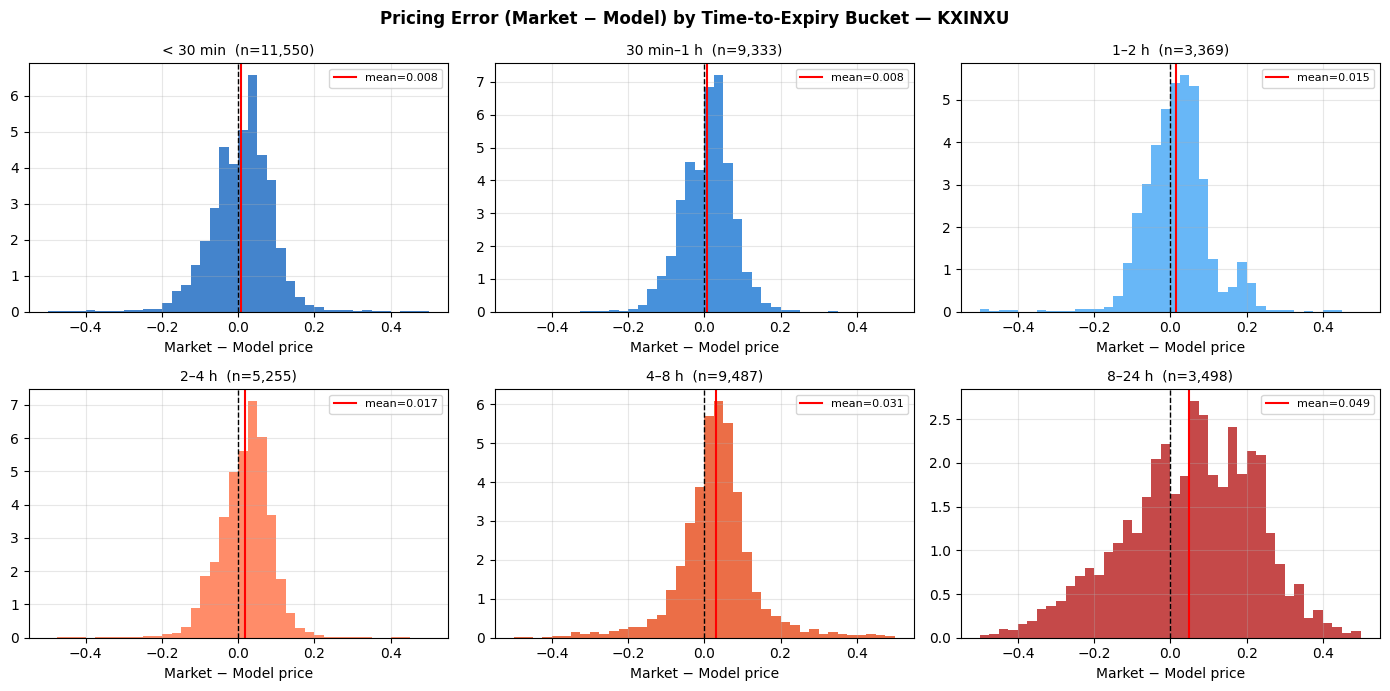

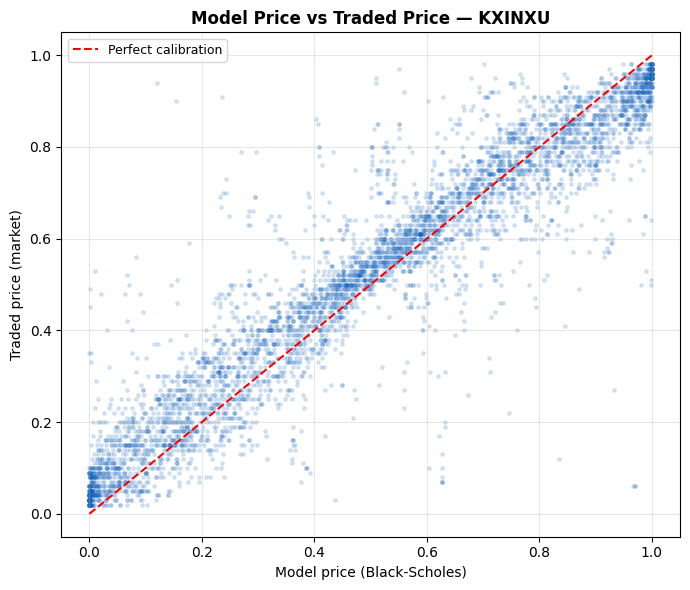

,N,Mean_Error,MAE,Std
TTE Bucket,,,,
< 30 min,11550,0.0079,0.0637,0.0867
30 min–1 h,9333,0.0081,0.0522,0.0662
1–2 h,3369,0.0150,0.0693,0.1044
2–4 h,5255,0.0168,0.0573,0.0809
4–8 h,9487,0.0307,0.0764,0.1055
8–24 h,3498,0.0486,0.1531,0.1847



Overall: N=42,492  Mean error=0.0180  MAE=0.0710


In [8]:
import re
import sys
from scipy.stats import norm

sys.path.insert(0, "src")
from Pricer import Pricer
pricer = Pricer()

# ── Merge KXINXU trades with nearest SPX/VIX (as-of join) ───────────────────
kxinxu_pd = kxinxu.to_pandas()
spx_pd2 = spx.to_pandas().sort_values("ts").drop_duplicates("ts")
vix_pd2 = vix.to_pandas().sort_values("ts").drop_duplicates("ts")
kxinxu_pd = kxinxu_pd.sort_values("ts")

kxinxu_pd = pd.merge_asof(kxinxu_pd, spx_pd2[["ts", "spx"]], on="ts", direction="backward")
kxinxu_pd = pd.merge_asof(kxinxu_pd, vix_pd2[["ts", "vix"]], on="ts", direction="backward")

# ── Parse threshold and compute hours to expiry ───────────────────────────────
def parse_expiry(ticker):
    months = {"JAN":1,"FEB":2,"MAR":3,"APR":4,"MAY":5,"JUN":6,"JUL":7,
              "AUG":8,"SEP":9,"OCT":10,"NOV":11,"DEC":12}
    m = re.search(r"-(\d{2})([A-Z]{3})(\d{2})H(\d{2})(\d{2})", ticker)
    if not m: return None
    from datetime import datetime
    yy,mon,dd,hh,mm = m.groups()
    mo = months.get(mon)
    return datetime(2000+int(yy), mo, int(dd), int(hh), int(mm)) if mo else None

kxinxu_pd["expiry"]    = kxinxu_pd["ticker"].apply(parse_expiry)
kxinxu_pd["ts_naive"]  = kxinxu_pd["ts"].dt.tz_localize(None)
kxinxu_pd["hours_tte"] = (kxinxu_pd["expiry"] - kxinxu_pd["ts_naive"]).dt.total_seconds() / 3600
kxinxu_pd["tau"]       = kxinxu_pd["hours_tte"] / (365 * 24)

# ── Compute model price using Pricer ─────────────────────────────────────────
def model_price(row):
    if pd.isna(row["spx"]) or pd.isna(row["vix"]) or pd.isna(row["tau"]) or row["tau"] <= 0:
        return np.nan
    return pricer.price(contract_id=row["ticker"], spx=row["spx"], vix=row["vix"], ts=row["ts"])

kxinxu_pd["model_price"] = kxinxu_pd.apply(model_price, axis=1)
kxinxu_pd["error"] = kxinxu_pd["price"] - kxinxu_pd["model_price"]

valid = kxinxu_pd.dropna(subset=["error", "hours_tte"])
valid = valid[(valid["price"] > 0.01) & (valid["price"] < 0.99) & (valid["hours_tte"] > 0)]
valid["tte_bucket"] = pd.cut(
    valid["hours_tte"],
    bins=[0, 0.5, 1, 2, 4, 8, 24],
    labels=["< 30 min", "30 min–1 h", "1–2 h", "2–4 h", "4–8 h", "8–24 h"]
)

# ── Chart 1: Error distribution by TTE bucket ────────────────────────────────
tte_order = ["< 30 min", "30 min–1 h", "1–2 h", "2–4 h", "4–8 h", "8–24 h"]
palette_tte = ["#1565c0", "#1976d2", "#42a5f5", "#ff7043", "#e64a19", "#b71c1c"]

fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharey=False)
axes = axes.flatten()
for i, (bucket, color) in enumerate(zip(tte_order, palette_tte)):
    subset = valid[valid["tte_bucket"] == bucket]["error"].dropna()
    if subset.empty:
        continue
    axes[i].hist(subset, bins=40, range=(-0.5, 0.5), color=color, alpha=0.8, density=True)
    axes[i].axvline(0, color="black", lw=1, ls="--")
    axes[i].axvline(subset.mean(), color="red", lw=1.5, ls="-", label=f"mean={subset.mean():.3f}")
    axes[i].set_title(f"{bucket}  (n={len(subset):,})", fontsize=10)
    axes[i].set_xlabel("Market − Model price")
    axes[i].legend(fontsize=8)
    axes[i].grid(alpha=0.3)

plt.suptitle("Pricing Error (Market − Model) by Time-to-Expiry Bucket — KXINXU", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

# ── Chart 2: Model vs market scatter ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
sample = valid.sample(min(5000, len(valid)), random_state=42)
ax.scatter(sample["model_price"], sample["price"], alpha=0.15, s=6, color="#1565c0", rasterized=True)
ax.plot([0, 1], [0, 1], color="red", lw=1.5, ls="--", label="Perfect calibration")
ax.set_xlabel("Model price (Black-Scholes)")
ax.set_ylabel("Traded price (market)")
ax.set_title("Model Price vs Traded Price — KXINXU", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
summary_tbl = (
    valid.groupby("tte_bucket", observed=True)["error"]
    .agg(
        N="count",
        Mean_Error="mean",
        MAE=lambda x: x.abs().mean(),
        Std="std",
    )
    .reset_index()
    .rename(columns={"tte_bucket": "TTE Bucket"})
)
summary_tbl[["Mean_Error", "MAE", "Std"]] = summary_tbl[["Mean_Error", "MAE", "Std"]].round(4)
display(summary_tbl.set_index("TTE Bucket"))
print(f"\nOverall: N={len(valid):,}  Mean error={valid['error'].mean():.4f}  MAE={valid['error'].abs().mean():.4f}")

# 3. Theory

George to-do?

# 4. Implementation

Max to-do?

## 4.1 Logic

### Pricing Logic:

### Market Making Logic: 

Base spread: FV +- .01 = .02. FV: Fair Value

The spread changes based off VIX & Current Inventory (Position Size):

VIX - For every point of VIX, the spread increases by .001. Ie. VIX = 20 -> spread increases by .02

Inventory - For every (Kalshi) contract in our inventory, the spread increases by .00025. Ie. 80 Contracts Held -> spread increases by .02

Outside of regular market hours (9:30 AM - 4:00 PM EST), the spread increases by .10 to account for the significantly lower liquidity & trade volume.

The spread midpoint is skewed away from the fair by (-).0005 * Kalshi Contract Position. Ie. Holding 40 "Yes" Contracts -> fair decreases by .02. This is done to reduce our axed position faster.

Finally, we build in Kalshi Maker Fees into our spread.

- Kalshi Maker Fees: fee = round up(0.0175 * C * P * (1 - P)), 
where P = price, C = number of contracts.

Our bids & offers are placed on the end of our spread.

We also manage our bid / ask size based on inventory (total & sided) to stay within the following parameters:
- Default Quote Size = 50
- Max Quote Size = 100
- Max Abs Inventory for Size = 500

### Simulation Logic:

The simulation seeks to mimic Kalshi

## 4.2 Program Architecture

In our implementation, we created a modular market making bot that currently interfaces with our simulator model. That follows the design below:

![System Architecture](Data/architecture.jpg)

### NOTE: NEED TO REFRESH DRAWING

## Data Ingestor

- **What it does:** Loads and standardizes 1-second Kalshi and market data from parquet files into structured Polars DataFrames.
- **Takes in:** Paths to Kalshi parquet file(s) (per-contract or cleaned trade-event), plus SPX, VIX, and SPY parquet files, as specified by the ingest config.
- **Sends out:** `all_df` (long-form combined Kalshi + macro data) to the Simulator for the main run; `macro_df` (SPX/VIX/SPY only) used by the ExecutionEngine.


## Simulator

- **What it does:** Drives the simulation by iterating over each second in chronological order. Each tick it calls the ExecutionEngine to get resting quotes and  hedging trades; applies a deterministic last-in-queue fill rule (e.g. bid filled when take_bid ≤ our_bid − .01); sends resulting fill intents to the engine. Produces a per-second, per-contract log of market snapshots, bot quotes, fill flags, and position state.
- **Takes in:** `all_df` (from DataIngestor). Each tick it receives resting quotes and hedge orders from the ExecutionEngine via the engine’s `on_tick` return value and applies them when evaluating fills.
- **Sends out:** `FillIntent` objects to the ExecutionEngine when a fill is detected; and a Polars DataFrame (one row per ts × contract_id) with the full log of market and bot behavior for analysis.


## Execution Engine

- **What it does:** Central gateway that coordinates pricing, quoting, hedging, and position updates. Each tick it applies any delayed trades due at that time (including SPY hedges with a 1-second delay), settles expired Kalshi contracts, requests fair values from the Pricer, pushes fair values and positions to the MarketMaker to get quotes, and asks the Delta Hedger for a hedge order (which it then schedules with delay). Kalshi fills from the Simulator are applied to the PositionManager immediately.
- **Takes in:** SPX, VIX, and SPY (and contract list) each tick from the Simulator, which reads them from the ingested data; fill intents from the Simulator when fills occur; internally it receives quotes from the MarketMaker and hedge orders from the Delta Hedger (both invoked inside the engine).
- **Sends out:** Fair-value requests to the Pricer; VIX, fair values, and position state to the MarketMaker; Kalshi fills and (when due) SPY trades to the PositionManager; current resting quotes to the Simulator; and hedge orders to the Simulator (execution applied with 1-second delay via the PositionManager).

## Pricer

- **What it does:** Computes the fair value (a probability in [0, 1]) of the "YES" side of each Kalshi SPX contract using a Black–Scholes-style lognormal terminal distribution. For threshold contracts (KXINXU), it prices a single binary call; for range contracts (KXINX), it replicates the payoff as a call spread (long binary call at lower strike, short at upper strike). Volatility is taken from VIX/100; time to expiry is parsed from the contract ID.
- **Takes in:** `contract_id`, `spx`, `vix`, and `ts` (current timestamp in UTC), passed by the ExecutionEngine each tick.
- **Sends out:** A fair value per contract. The ExecutionEngine forwards these values to the MarketMaker and uses them for quoting.

## Market Maker

- **What it does:** Produces bid/ask quotes and sizes for each contract from the latest fair value, VIX, and position state. Spread is widened by base spread plus terms for VIX and absolute inventory; the mid is skewed away from fair value based on inventory to mean-revert (e.g. long inventory → lower mid to encourage selling). Sizes can be tilted (e.g. larger ask when long) and are reduced as inventory grows. Optionally widens spread outside regular market hours (9:30–16:00 ET). Prices are rounded to tick size and clamped to [0, 1].
- **Takes in:** Fair value per contract (from Pricer via ExecutionEngine), VIX and market-hours flag (from ExecutionEngine), and per-contract inventory/cash (from PositionManager via ExecutionEngine).
- **Sends out:** A `Quote` per contract (contract_id, fair_value, bid, ask, bid_size, ask_size, spread, meta). The ExecutionEngine collects these and sends the resulting resting quotes to the Simulator.

## Position Manager

- **What it does:** Tracks Kalshi positions by contract, SPY position, and cash. Applies Kalshi fills (from the Simulator via ExecutionEngine) immediately, updating inventory and cash. Applies SPY hedge trades when their delayed execution time is reached. At each tick, settles any Kalshi contracts that have expired (settlement at start of next day after expiry) by paying out 0 or 1 per contract and removing them from the book.
- **Takes in:** Kalshi trade events (contract_id, side, qty, price) from ExecutionEngine when fills occur; SPY trade events (side, qty, price) when delayed hedge trades execute; current timestamp and settlement SPX for deciding which contracts to settle.
- **Sends out:** Per-contract Kalshi inventory, total SPY position, and cash balance. The ExecutionEngine reads these (e.g. `get_kalshi_position`, `get_kalshi_positions`, `get_spy_position`, `get_cash`) and passes them to the MarketMaker and Delta Hedger; it also uses them when applying fills and scheduling hedge trades.

## Delta Hedger

- **What it does:** Computes the aggregate delta of the Kalshi book in SPX terms using the binary-option delta formula (φ(d2) / (S × σ × √τ)) per contract, then maps that to a target SPY share position via a configurable SPX-to-SPY scaling (e.g. dSPY/dSPX ≈ 0.1 → shares ≈ −10 × delta_book_spx). Produces a single hedge order (buy or sell SPY) to move the current SPY position toward the target, with optional cap on size per tick.
- **Takes in:** Current timestamp `ts`, `spy_price`, `spx_price`, `vix`, full `kalshi_positions` (contract_id → qty), and `current_spy_position`, all provided by the ExecutionEngine each tick from market data and the PositionManager.
- **Sends out:** A `HedgeOrder` (ts, symbol, side, qty, ref_price) or `None` if no rehedge is needed. The ExecutionEngine schedules the trade with a 1-second execution delay and later sends it to the Simulator; when the delay elapses, the engine applies the trade through the PositionManager.

# 5. Results & Analysis